In [19]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sebastianube19","key":"a3dd6f3ce7cf81dae692beddfbbb7280"}'}

In [20]:
import os

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

os.system('pip install -q kaggle')
os.system('kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification')

import zipfile
with zipfile.ZipFile('fruits-fresh-and-rotten-for-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/fruits-fresh-and-rotten-for-classification')

print("Dataset listo!")

Dataset listo!


In [21]:
!pip install -q tf-keras-vis seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

TRAIN_DIR = '/content/fruits-fresh-and-rotten-for-classification/dataset/dataset/train'
TEST_DIR = '/content/fruits-fresh-and-rotten-for-classification/dataset/dataset/test'

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [22]:
def contar_imagenes(directorio):
    conteo = {}
    for clase in sorted(os.listdir(directorio)):
        ruta = os.path.join(directorio, clase)
        if os.path.isdir(ruta):
            conteo[clase] = len(os.listdir(ruta))
    return conteo

train_conteo = contar_imagenes(TRAIN_DIR)
test_conteo = contar_imagenes(TEST_DIR)

df = pd.DataFrame({'Train': train_conteo, 'Test': test_conteo})
df['Total'] = df['Train'] + df['Test']
print(df)
print(f"\nTotal imágenes: {df['Total'].sum()}")

               Train  Test  Total
freshapples     1693   395   2088
freshbanana     1581   381   1962
freshoranges    1466   388   1854
rottenapples    2342   601   2943
rottenbanana    2224   530   2754
rottenoranges   1595   403   1998

Total imágenes: 13599


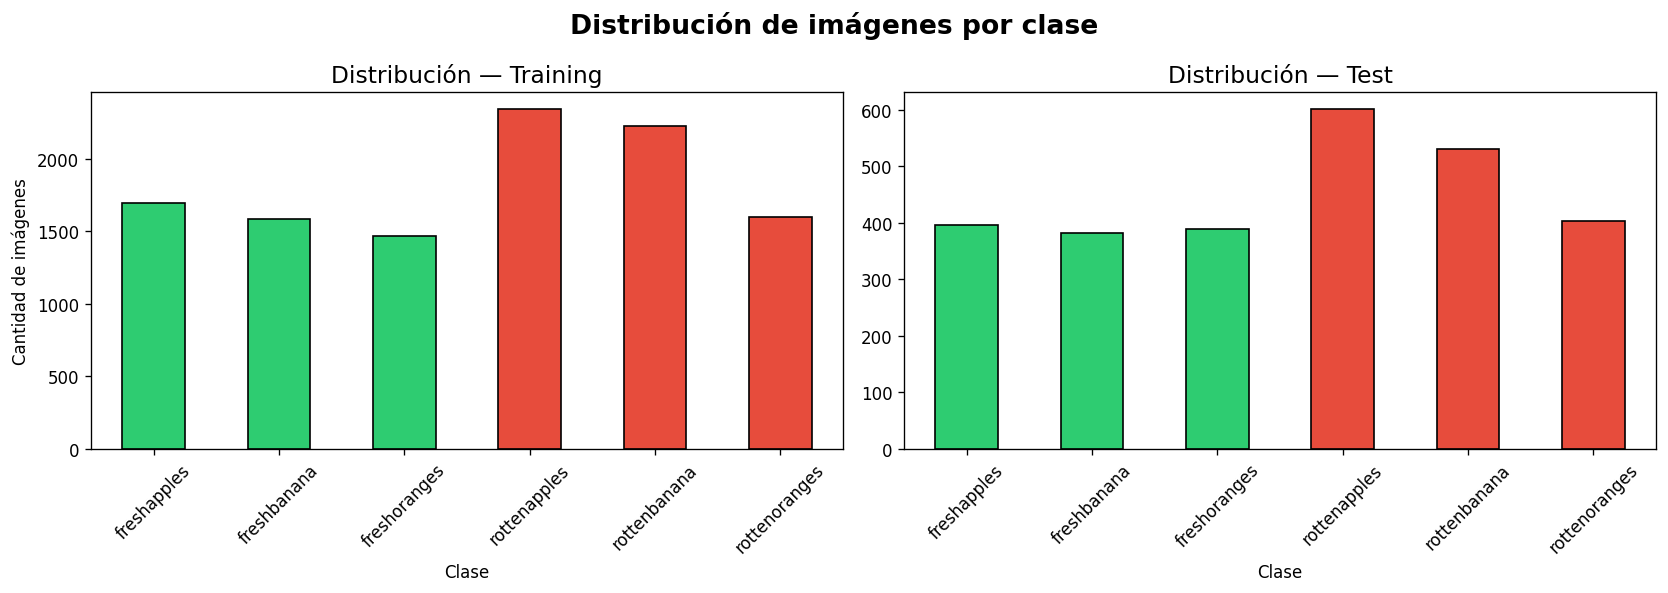

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#2ecc71' if 'fresh' in c else '#e74c3c' for c in df.index]

df['Train'].plot(kind='bar', ax=axes[0], color=colores, edgecolor='black')
axes[0].set_title('Distribución — Training', fontsize=14)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].tick_params(axis='x', rotation=45)

df['Test'].plot(kind='bar', ax=axes[1], color=colores, edgecolor='black')
axes[1].set_title('Distribución — Test', fontsize=14)
axes[1].set_xlabel('Clase')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de imágenes por clase', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png')
plt.show()

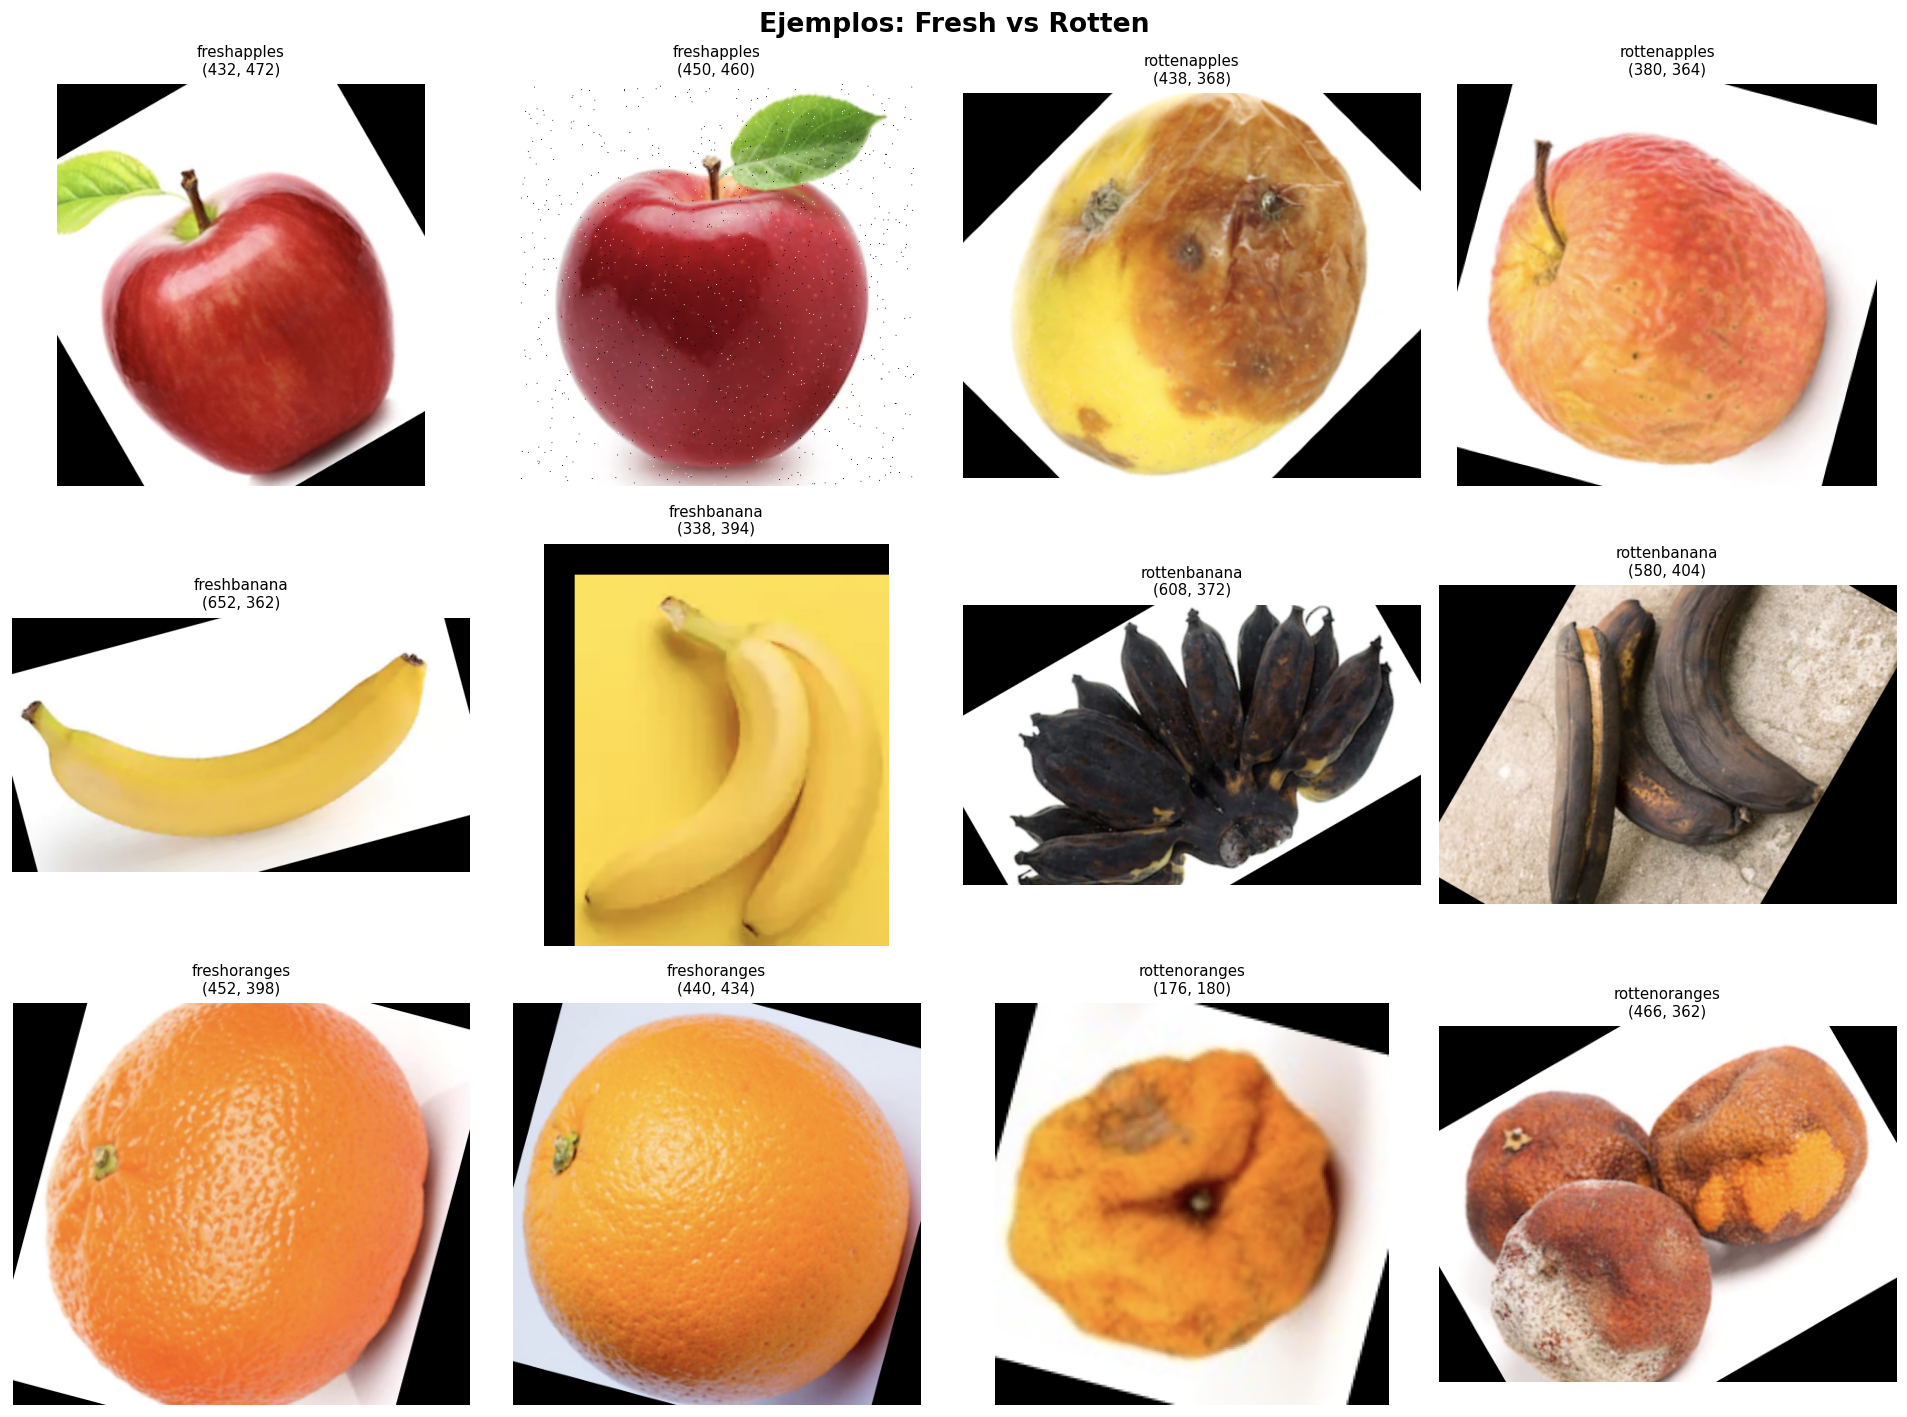

In [24]:
clases_pares = [
    ('freshapples', 'rottenapples'),
    ('freshbanana', 'rottenbanana'),
    ('freshoranges', 'rottenoranges')
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, (fresca, podrida) in enumerate(clases_pares):
    for j, clase in enumerate([fresca, podrida]):
        ruta_clase = os.path.join(TRAIN_DIR, clase)
        imagenes = os.listdir(ruta_clase)[:2]
        for k, img_nombre in enumerate(imagenes):
            img = Image.open(os.path.join(ruta_clase, img_nombre))
            ax = axes[i][j*2 + k]
            ax.imshow(img)
            ax.set_title(f'{clase}\n{img.size}', fontsize=9)
            ax.axis('off')

plt.suptitle('Ejemplos: Fresh vs Rotten', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ejemplos_frutas.png')
plt.show()

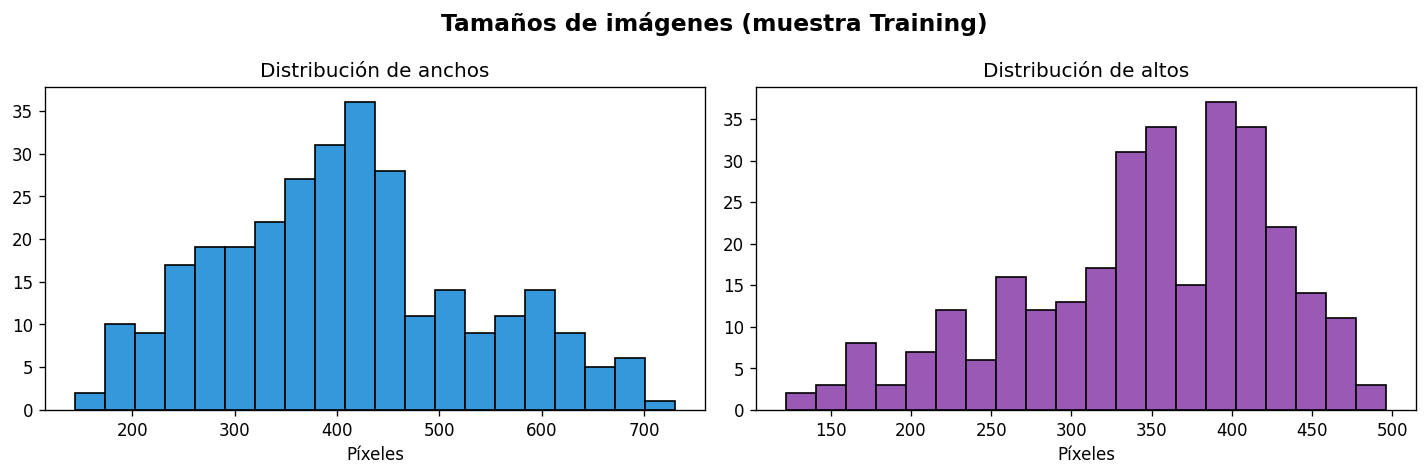

Ancho promedio: 408px | Alto promedio: 347px


In [25]:
anchos, altos, clases_lista = [], [], []

for clase in os.listdir(TRAIN_DIR):
    ruta_clase = os.path.join(TRAIN_DIR, clase)
    for img_nombre in os.listdir(ruta_clase)[:50]:
        try:
            img = Image.open(os.path.join(ruta_clase, img_nombre))
            anchos.append(img.size[0])
            altos.append(img.size[1])
            clases_lista.append(clase)
        except:
            pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(anchos, bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('Distribución de anchos')
axes[0].set_xlabel('Píxeles')

axes[1].hist(altos, bins=20, color='#9b59b6', edgecolor='black')
axes[1].set_title('Distribución de altos')
axes[1].set_xlabel('Píxeles')

plt.suptitle('Tamaños de imágenes (muestra Training)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_tamanos.png')
plt.show()

print(f"Ancho promedio: {np.mean(anchos):.0f}px | Alto promedio: {np.mean(altos):.0f}px")

In [26]:
corruptas = []

for split, directorio in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    for clase in os.listdir(directorio):
        ruta_clase = os.path.join(directorio, clase)
        for img_nombre in os.listdir(ruta_clase):
            try:
                img = Image.open(os.path.join(ruta_clase, img_nombre))
                img.verify()
            except Exception as e:
                corruptas.append({'split': split, 'clase': clase, 'archivo': img_nombre})

if corruptas:
    print(f" {len(corruptas)} imágenes corruptas encontradas:")
    print(pd.DataFrame(corruptas))
else:
    print("No se encontraron imágenes corruptas")

No se encontraron imágenes corruptas


In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

datagen_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

datagen_test = ImageDataGenerator(rescale=1./255)

train_gen = datagen_train.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = datagen_train.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = datagen_test.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClases: {train_gen.class_indices}")

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.

Clases: {'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [28]:
from tensorflow.keras import layers, models

def crear_cnn_baseline():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(6, activation='softmax')
    ])
    return model

baseline = crear_cnn_baseline()
baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,550 (6.61 MB)

 Trainable params: 1,732,550 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_baseline = baseline.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    verbose=1
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 218s 792ms/step - accuracy: 0.6225 - loss: 0.9583 - val_accuracy: 0.8650 - val_loss: 0.4544
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 216s 790ms/step - accuracy: 0.8115 - loss: 0.5156 - val_accuracy: 0.9040 - val_loss: 0.2757
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 225s 823ms/step - accuracy: 0.8685 - loss: 0.3807 - val_accuracy: 0.8843 - val_loss: 0.3175
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 210s 768ms/step - accuracy: 0.8905 - loss: 0.3124 - val_accuracy: 0.8999 - val_loss: 0.2591
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 211s 771ms/step - accuracy: 0.9075 - loss: 0.2615 - val_accuracy: 0.9412 - val_loss: 0.1587
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 218s 797ms/step - accuracy: 0.9191 - loss: 0.2305 - val_accuracy: 0.9224 - val_loss: 0.1909
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 211s 774ms/step - accuracy: 0.9304 - loss: 0.1923 - val_accuracy: 0.9651 - val_loss: 0.0940
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 216s 789ms/step - accuracy: 0.9340 -

Test Accuracy: 0.9629 | Test Loss: 0.1059


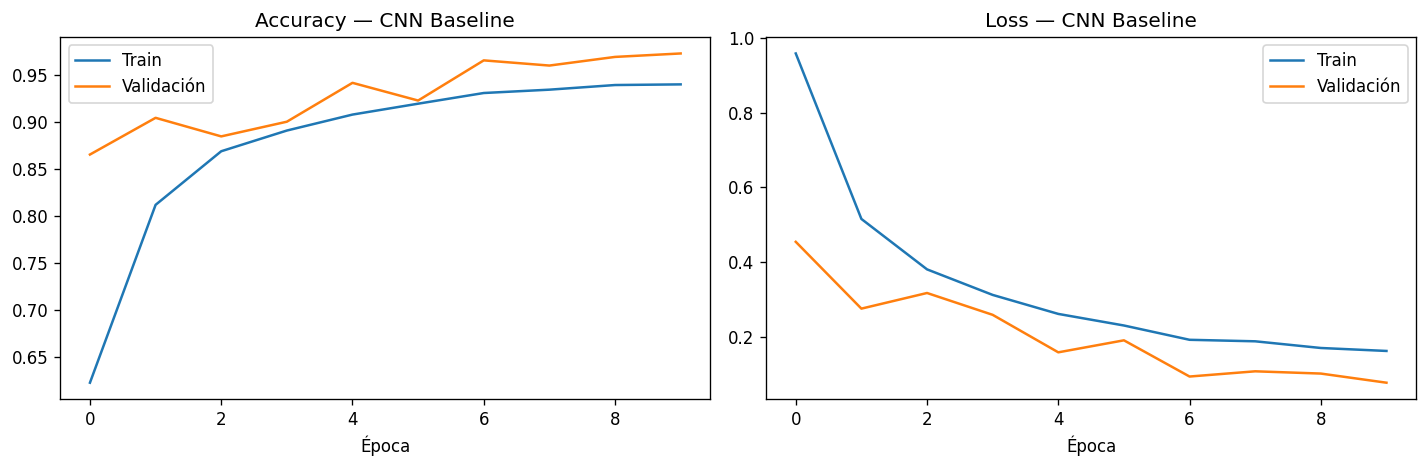

85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 292ms/step

                precision    recall  f1-score   support

  freshapples       0.93      0.99      0.96       395
  freshbanana       1.00      0.98      0.99       381
 freshoranges       0.96      0.97      0.96       388
 rottenapples       0.94      0.94      0.94       601
 rottenbanana       0.99      1.00      0.99       530
rottenoranges       0.98      0.89      0.93       403

     accuracy                           0.96      2698
    macro avg       0.96      0.96      0.96      2698
 weighted avg       0.96      0.96      0.96      2698



In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluación en test
loss, acc = baseline.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history['accuracy'], label='Train')
axes[0].plot(history_baseline.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy — CNN Baseline')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_baseline.history['loss'], label='Train')
axes[1].plot(history_baseline.history['val_loss'], label='Validación')
axes[1].set_title('Loss — CNN Baseline')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_baseline.png')
plt.show()

# F1-score
test_gen.reset()
y_pred = np.argmax(baseline.predict(test_gen), axis=1)
y_true = test_gen.classes
print("\n", classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(100, 100, 3)
)

base_model.trainable = False  # Congelar capas base

# Agregar capas propias
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(6, activation='softmax')(x)

mobilenet = Model(inputs=base_model.input, outputs=output)

mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Capas totales: {len(mobilenet.layers)}")
print(f"Capas entrenables: {len([l for l in mobilenet.layers if l.trainable])}")

Capas totales: 158
Capas entrenables: 4


In [32]:
history_mobilenet = mobilenet.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    verbose=1
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 135s 470ms/step - accuracy: 0.9007 - loss: 0.2824 - val_accuracy: 0.9702 - val_loss: 0.0732
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 146s 537ms/step - accuracy: 0.9633 - loss: 0.1020 - val_accuracy: 0.9738 - val_loss: 0.0665
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 129s 473ms/step - accuracy: 0.9758 - loss: 0.0693 - val_accuracy: 0.9757 - val_loss: 0.0715
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 125s 459ms/step - accuracy: 0.9853 - loss: 0.0442 - val_accuracy: 0.9881 - val_loss: 0.0373
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 141s 515ms/step - accuracy: 0.9844 - loss: 0.0400 - val_accuracy: 0.9908 - val_loss: 0.0303
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 125s 459ms/step - accuracy: 0.9885 - loss: 0.0333 - val_accuracy: 0.9904 - val_loss: 0.0304
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 124s 456ms/step - accuracy: 0.9874 - loss: 0.0346 - val_accuracy: 0.9876 - val_loss: 0.0309
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 126s 463ms/step - accuracy: 0.9888 -

Test Accuracy: 0.9855 | Test Loss: 0.0485


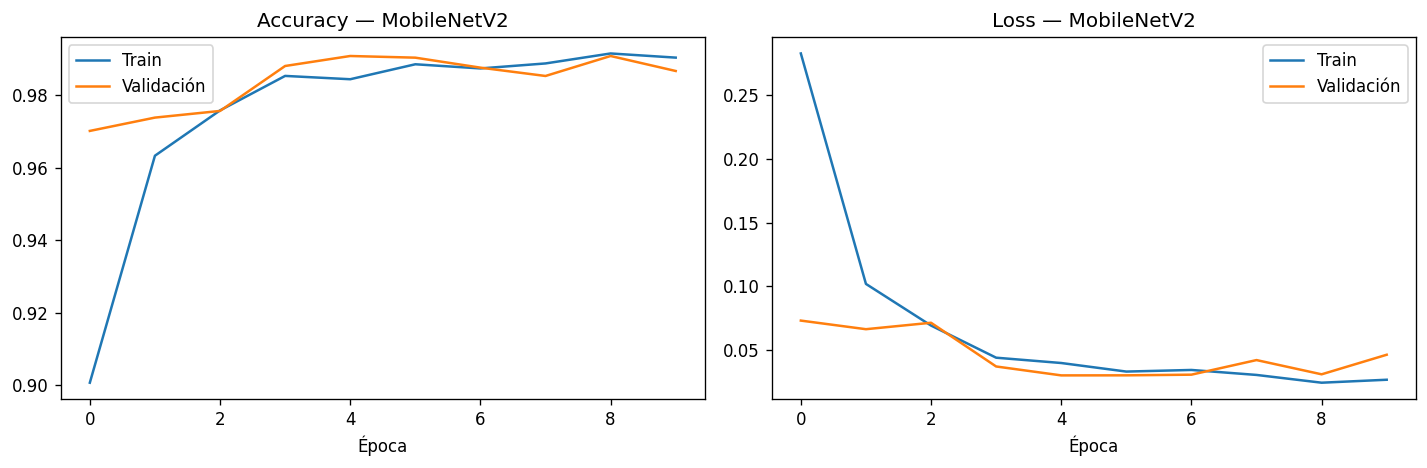

85/85 ━━━━━━━━━━━━━━━━━━━━ 37s 413ms/step

                precision    recall  f1-score   support

  freshapples       0.96      1.00      0.98       395
  freshbanana       0.99      1.00      0.99       381
 freshoranges       0.98      0.97      0.98       388
 rottenapples       0.99      0.98      0.98       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.98      0.97      0.97       403

     accuracy                           0.99      2698
    macro avg       0.98      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



In [33]:
loss, acc = mobilenet.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {acc:.4f} | Test Loss: {loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mobilenet.history['accuracy'], label='Train')
axes[0].plot(history_mobilenet.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy — MobileNetV2')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history_mobilenet.history['loss'], label='Train')
axes[1].plot(history_mobilenet.history['val_loss'], label='Validación')
axes[1].set_title('Loss — MobileNetV2')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_mobilenet.png')
plt.show()

test_gen.reset()
y_pred = np.argmax(mobilenet.predict(test_gen), axis=1)
y_true = test_gen.classes
print("\n", classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

In [34]:
mobilenet.save('modelo_frutas.h5')
print("Modelo guardado como modelo_frutas.h5")

Modelo guardado como modelo_frutas.h5


In [35]:
!pip install -q tf-keras-vis

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

print("tf-keras-vis listo")

tf-keras-vis listo


In [36]:
def gradcam_overlay(ruta_imagen):
    # Cargar y convertir a RGB (por si tiene canal alpha)
    img = Image.open(ruta_imagen).convert('RGB').resize((100, 100))
    img_array = np.array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Predecir
    pred = mobilenet.predict(img_input, verbose=0)
    clase_idx = np.argmax(pred)
    clases = list(train_gen.class_indices.keys())
    clase_nombre = clases[clase_idx]
    confianza = pred[0][clase_idx] * 100

    # Generar Grad-CAM
    gradcam = Gradcam(mobilenet, model_modifier=ReplaceToLinear(), clone=True)
    score = CategoricalScore([clase_idx])
    cam = gradcam(score, img_input, penultimate_layer=-1)

    # Superponer heatmap
    heatmap = cam[0]
    heatmap = cv2.resize(heatmap, (100, 100))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_original = np.uint8(img_array * 255)
    overlay = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

    # Mostrar
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_original)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(heatmap_color)
    axes[1].set_title('Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f'Predicción: {clase_nombre}\nConfianza: {confianza:.1f}%')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return overlay, clase_nombre, confianza

print("Función gradcam_overlay lista")

Función gradcam_overlay lista



--- freshapples ---


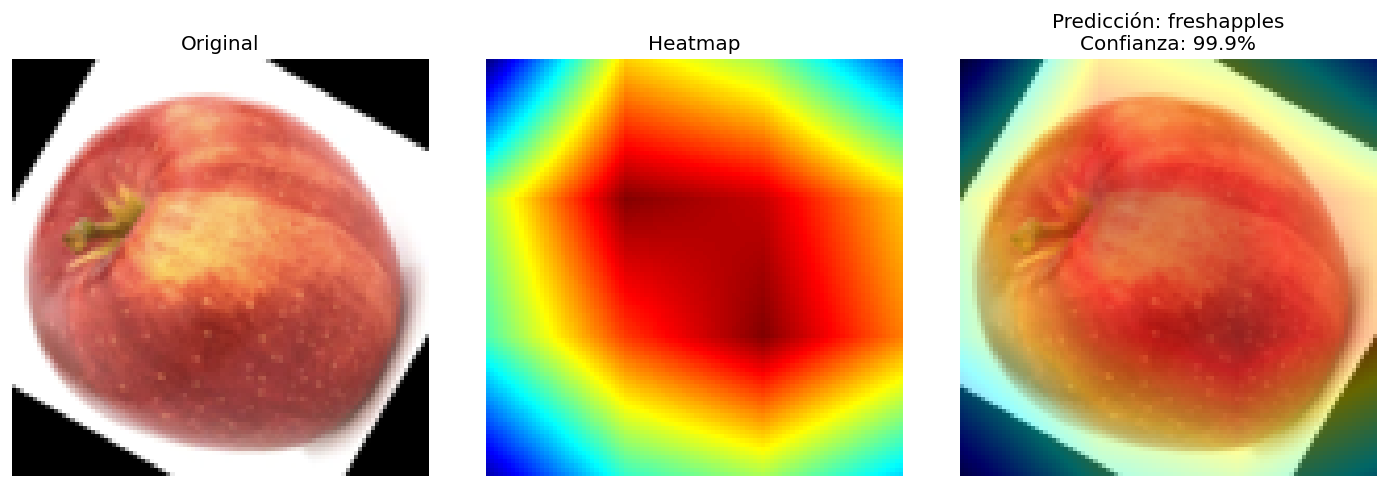


--- rottenapples ---


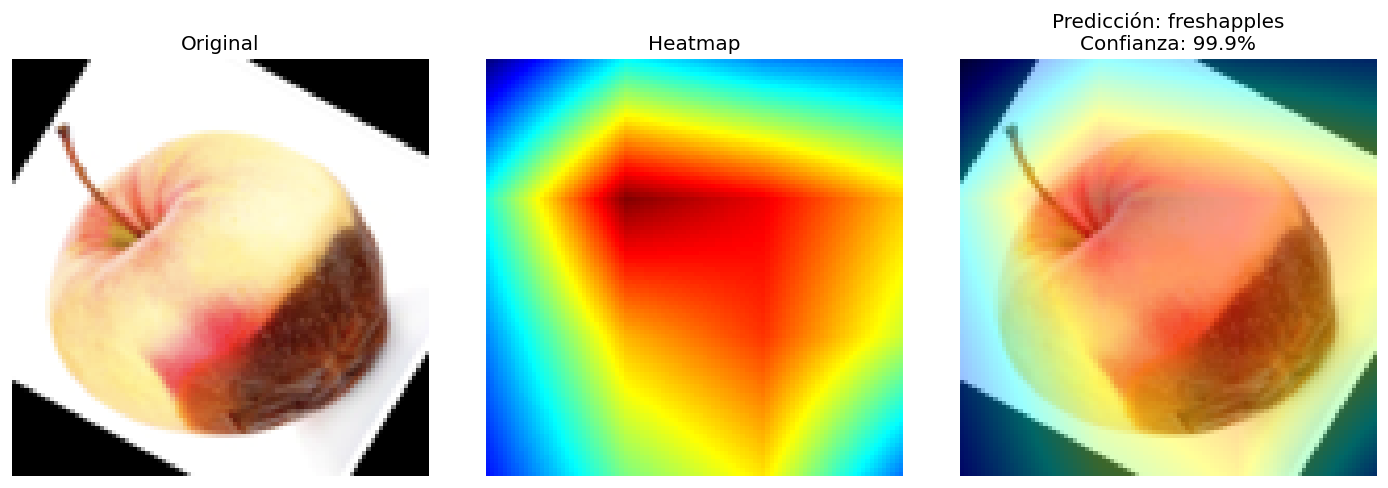


--- freshbanana ---


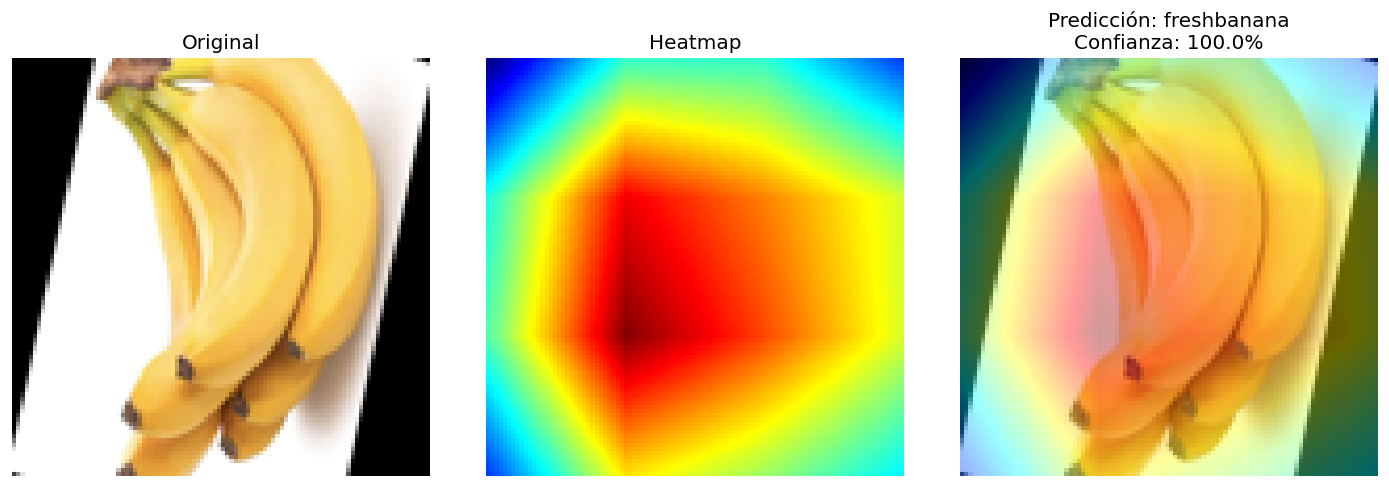


--- rottenbanana ---


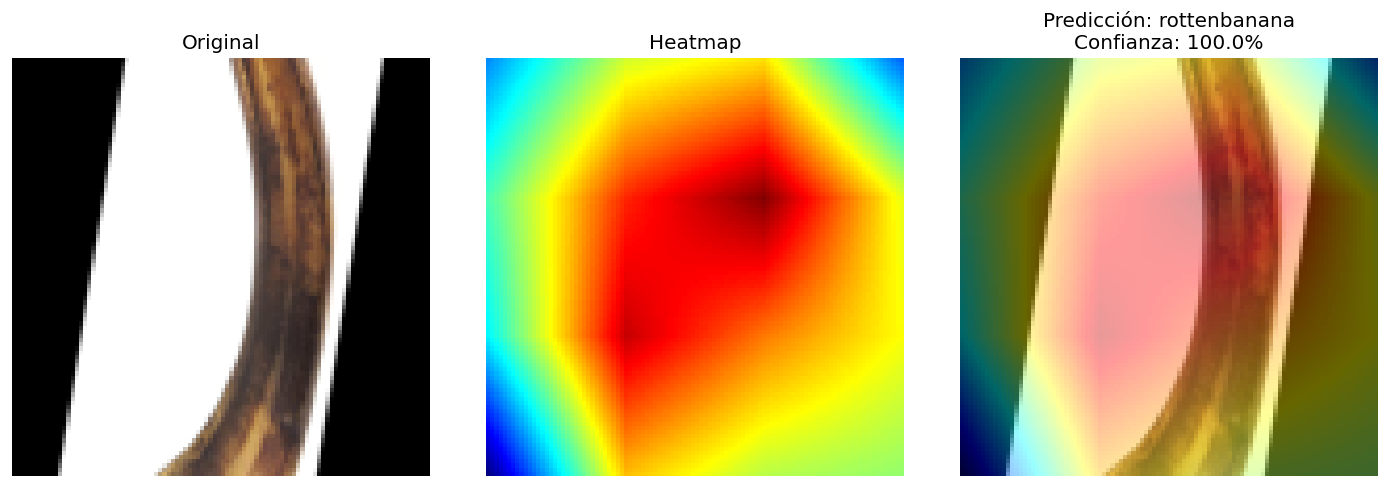


--- freshoranges ---


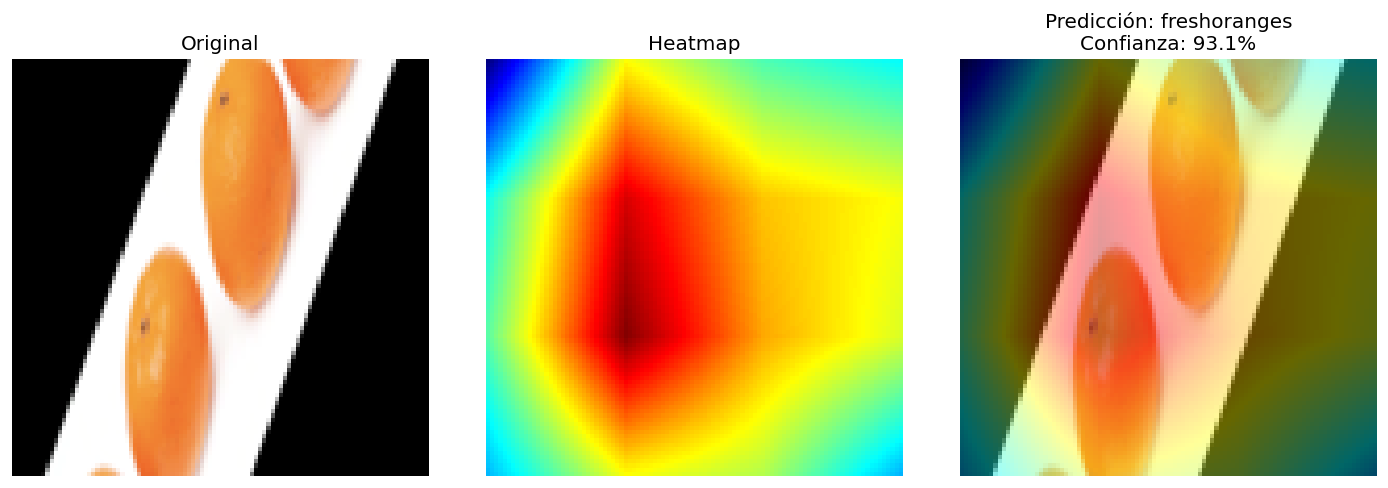

In [37]:
import random

# Tomar una imagen de cada clase
clases_prueba = ['freshapples', 'rottenapples', 'freshbanana', 'rottenbanana', 'freshoranges']

for clase in clases_prueba:
    ruta_clase = os.path.join(TEST_DIR, clase)
    imagen = random.choice(os.listdir(ruta_clase))
    ruta_completa = os.path.join(ruta_clase, imagen)
    print(f"\n--- {clase} ---")
    gradcam_overlay(ruta_completa)

In [38]:
from google.colab import files
files.download('modelo_frutas.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 370ms/step


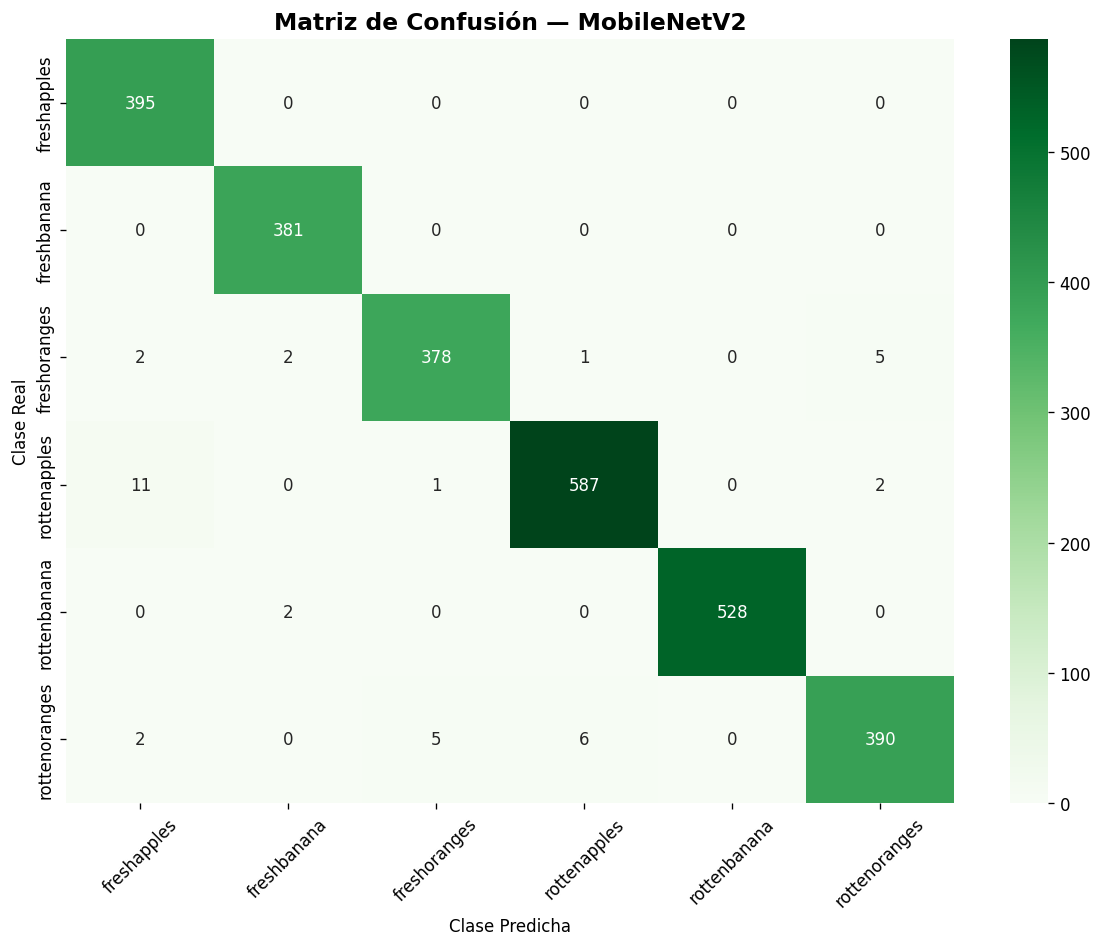

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_gen.reset()
y_pred = np.argmax(mobilenet.predict(test_gen), axis=1)
y_true = test_gen.classes
clases_nombres = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=clases_nombres, yticklabels=clases_nombres)
plt.title('Matriz de Confusión — MobileNetV2', fontsize=14, fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('matriz_confusion.png')
plt.show()

85/85 ━━━━━━━━━━━━━━━━━━━━ 44s 523ms/step


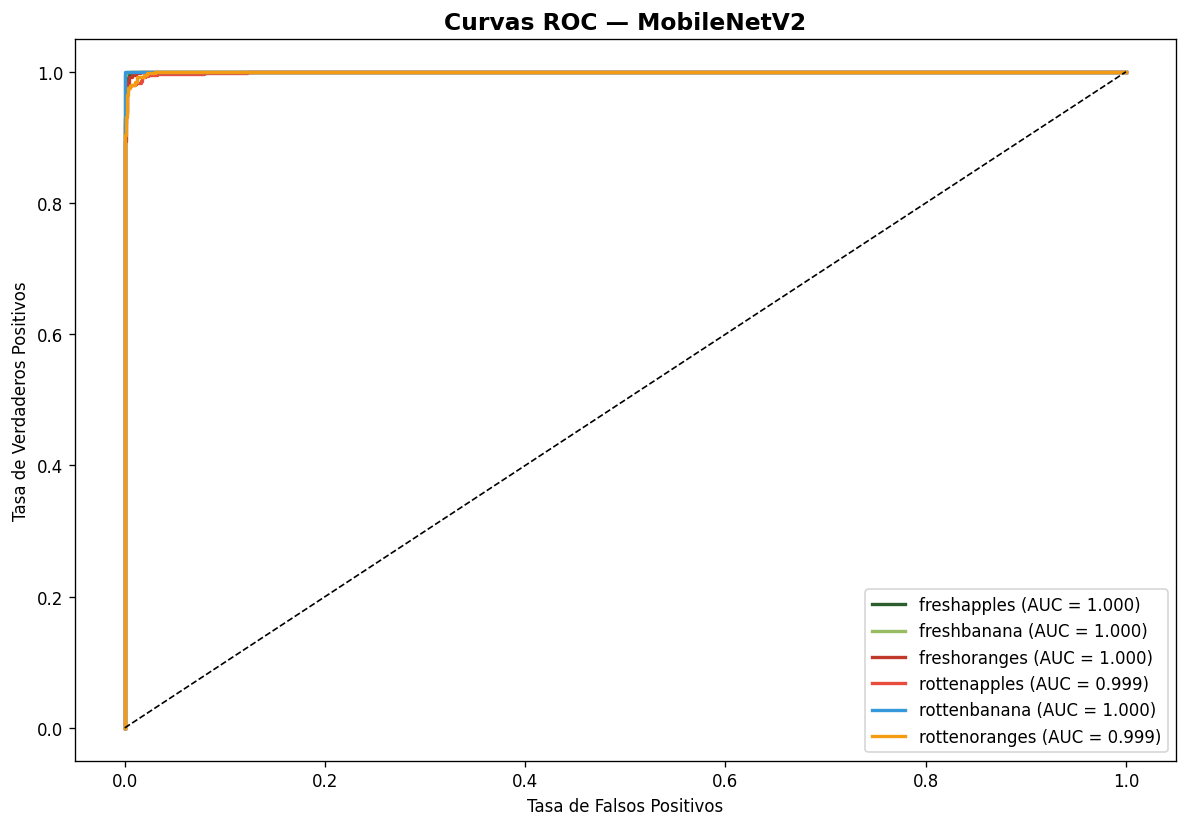

In [40]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

test_gen.reset()
y_scores = mobilenet.predict(test_gen)
y_true_bin = label_binarize(y_true, classes=list(range(6)))

plt.figure(figsize=(10, 7))
colors = ['#2C5F2D', '#97BC62', '#C0392B', '#E74C3C', '#3498DB', '#F39C12']

for i, (clase, color) in enumerate(zip(clases_nombres, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{clase} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC — MobileNetV2', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_auc.png')
plt.show()

In [41]:
from google.colab import files
files.download('matriz_confusion.png')
files.download('roc_auc.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>